<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4-feature-extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Extraction (Extracción de Características)
Nota: Para efectos prácticos, se recomienda ejecutar este notebook preferiblemente en Google Colab. Dada su compatibilidad con kagglehub, esto nos permite importar la base de datos directamente desde Kaggle, optimizando el proceso al evitar la descarga manual de los archivos y el uso innecesario de espacio en memoria, tanto local como en la nube.

Si desea ejecutarlo de forma local, tenga en cuenta que en otros proyectos las bases de datos pueden ocupar un espacio considerable; una vez descargadas, deberá ajustar las rutas de acceso según corresponda.

# RAVDESS – Descripción del dataset

El Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS) es un conjunto de datos multimodal utilizado para reconocimiento de emociones en audio y procesamiento del habla.

## Características generales
- 7356 archivos en total - **1440 solamente audio**  
- 24 actores (12 hombres, 12 mujeres)  
- Dos frases en inglés con contenido similar  
- Grabaciones en acento norteamericano  

## Emociones
- 01: neutral  
- 02: calm  
- 03: happy  
- 04: sad  
- 05: angry  
- 06: fearful  
- 07: disgust  
- 08: surprised  

## Modalidades
- Audio (.wav, 48kHz, 16-bit)  
- Audio + video  
- Video sin audio  

## Intensidad
- 01: normal  
- 02: fuerte  
- (neutral solo tiene intensidad normal)  

## Estructura
ravdess/
├── Actor_01/
├── Actor_02/
...
├── Actor_24/

## Convención de nombres
Formato:
modality-vocal_channel-emotion-intensity-statement-repetition-actor.wav

Ejemplo:
03-01-06-01-02-01-12.wav

## Significado de campos
| Pos | Campo          | Descripción |
|-----|----------------|-------------|
| 1   | Modality       | 01=audio+video, 02=video, 03=audio |
| 2   | Vocal channel  | 01=speech, 02=song |
| 3   | Emotion        | ver lista de emociones |
| 4   | Intensity      | 01=normal, 02=fuerte |
| 5   | Statement      | 01=kids..., 02=dogs... |
| 6   | Repetition     | 01=primera, 02=segunda |
| 7   | Actor          | 01–24 (impar=hombre, par=mujer) |

## Ejemplo interpretado
03-01-06-01-02-01-12.wav

- audio  
- speech  
- fearful  
- intensidad normal  
- frase 2  
- repetición 1  
- actor 12 (mujer)

In [1]:
import kagglehub
import os
from google.colab import drive
drive.mount('/content/drive')
# Download latest version (Nota desde Kaggle)
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
BASE_DIR = "/kaggle/input/ravdess-emotional-speech-audio"

print("Path to dataset files:", path)
print("\n")

# Listar el contenido del directorio del dataset para comprobar su contenido
print(f"Contenido de la carpeta del dataset: {path}")
print(os.listdir(BASE_DIR))

Mounted at /content/drive
Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Path to dataset files: /kaggle/input/ravdess-emotional-speech-audio


Contenido de la carpeta del dataset: /kaggle/input/ravdess-emotional-speech-audio
['Actor_02', 'Actor_17', 'Actor_05', 'Actor_16', 'Actor_21', 'Actor_01', 'Actor_11', 'Actor_20', 'Actor_08', 'Actor_15', 'Actor_06', 'Actor_12', 'Actor_23', 'Actor_24', 'Actor_22', 'Actor_04', 'Actor_19', 'Actor_10', 'Actor_09', 'audio_speech_actors_01-24', 'Actor_14', 'Actor_03', 'Actor_13', 'Actor_18', 'Actor_07']


In [2]:
# Reproduccion de un archivo con un clip -05- (Angry)
import IPython.display as ipd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import logging
import sys
base_dir_actor_01 = "/kaggle/input/ravdess-emotional-speech-audio/Actor_01"
angry_clip = os.path.join(base_dir_actor_01, "03-01-05-02-02-01-01.wav")
ipd.Audio(angry_clip)

### **Procesamiento de Duración y Eliminación de Silencios**


Para lograr un correcto procesamiento de los clips, es necesario establecer una misma duración en todos los archivos. Para ello, utilizaremos la función trim de la librería Librosa, que permite eliminar los silencios según un umbral determinado.

Como podemos ver a continuación, si se aplica un criterio muy agresivo —por ejemplo, realizando el trim a sonidos 20 dB por debajo del umbral máximo del clip—, se corre el riesgo de perder información valiosa. Por esta razón, se ha determinado que un top_db=40 es un valor adecuado: no es tan agresivo como para cortar segmentos silenciosos que aún contienen información relevante, ni tan permisivo como para conservar silencios que carecen de importancia.

Text(0.5, 1.0, 'Trim 40 dB')

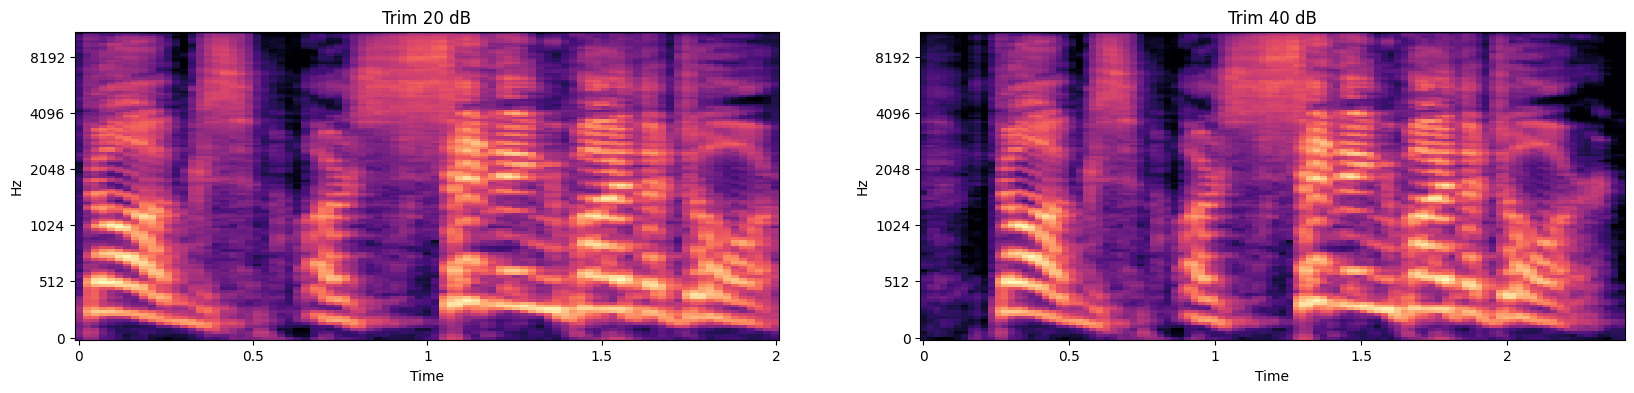

In [3]:
SAMPLE_RATE = 22050
signal, sr = librosa.load(angry_clip, sr=SAMPLE_RATE)

signal_out_20, _ = librosa.effects.trim(signal, top_db=20)
mel_trimm_20 = librosa.feature.melspectrogram(y=signal_out_20, sr=sr, n_mels=128)
mel_trimm_20_db = librosa.power_to_db(mel_trimm_20, ref=np.max)

signal_out_40, _ = librosa.effects.trim(signal, top_db=40)
mel_trimm_40 = librosa.feature.melspectrogram(y=signal_out_40, sr=sr, n_mels=128)
mel_trimm_40_db = librosa.power_to_db(mel_trimm_40, ref=np.max)

plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 1) #1 Fila, 2 columnas, 1er plot
librosa.display.specshow(mel_trimm_20_db,
                         sr=sr,
                         x_axis='time',
                         y_axis='mel')
plt.title('Trim 20 dB')

plt.subplot(1, 2, 2) #1 Fila, 2 columnas, 2do plot
librosa.display.specshow(mel_trimm_40_db,
                         sr=sr,
                         x_axis='time',
                         y_axis='mel')
plt.title('Trim 40 dB')

In [4]:
ipd.Audio(signal_out_20, rate=sr)

In [5]:
ipd.Audio(signal_out_40, rate=sr)

In [12]:
# Extraccion de caracteristicas (De audio a dataframe - csv):


#--------------------------------------------------------------------------
# Variables de configuración
DATASET_PATH = '/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24'
SAMPLE_RATE = 22050
MIN_DURATION = 0.5
MAX_DURATION = 4
GENERATE_CSV = False
GENERATE_IMAGES = False # Poner en False para solo obtener DF (Parte CSV)
PAD_MODE = "constant" # Para padding de audios cortos
OUT_DIR_IMAGES = '/content/drive/MyDrive/ravdess_images/'
OUT_DIR_IMAGES_02 = '/content/drive/MyDrive/ravdess_images_02/'
OUT_DIR_CSV = '/content/drive/MyDrive/ravdess_features/features.csv'
BATCH_SIZE_CSV = 60 # Depende cuanto RAM usemos
IMG_RES_01 = (256,128)
IMG_RES_02 = (128,128)
IMG_RES_03 = (512,256) # Multiples resoluciones para pruebas posteriores
#--------------------------------------------------------------------------

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    stream=sys.stdout,
                    force=True
                    )

#Contadores para proceso de los cliops

processed_count=0
discarded_count=0
error_count=0

# Funciones para la extraccion:

# Sabemos que en eg. RAVDESS: 03-01-XX-01-01-01-01.wav -> XX= corresponde a la emoción)

# Función para agrupar por emoción
def get_emotion_from_filename(filename):
    try:
        parts = filename.split('-')
        emotion_code = int(parts[2]) # Posicion donde está XX
        emotion_map = {1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}
        return emotion_map.get(emotion_code, 'unknown')
    except:
        return 'unknown'

# Función process_audio
def process_audio(file_path, sr=SAMPLE_RATE, min_dur=MIN_DURATION, max_dur=MAX_DURATION):
    global discarded_count, error_count
    try:
        # Como vimos, es mas conveninete no ser tan agresivos y se procede a usar 40 en top_db
        y, sr = librosa.load(file_path, sr=sr)
        y_trimmed, _ = librosa.effects.trim(y, top_db=40)
        duration = len(y_trimmed) / sr

        # No necesario si se normaliza, y se configurta la res de la imagen de salida.
        if duration < min_dur or duration > max_dur:
            logging.info(f"Descartado {os.path.basename(file_path)}: duración {duration:.2f}s")
            discarded_count += 1
            return None
        target_len = int(max_dur * sr)
        if len(y_trimmed) < target_len:
            y_trimmed = np.pad(y_trimmed, (0, target_len - len(y_trimmed)), mode=PAD_MODE)
        y_trimmed = librosa.util.normalize(y_trimmed)
        return y_trimmed, sr
    except Exception as e:
        logging.error(f"Error en {file_path}: {e}")
        discarded_count += 1
        return None

'''
En esta etapa, procederemos a extraer 8 características fundamentales de cada clip de audio.
Cabe destacar que, en muchos de los scripts que trabajan con el conjunto de datos RAVDESS,
no es habitual incluir los coeficientes Delta y Delta-Delta. Sin embargo, en pro de la experimentación
y el aprendizaje, hemos decidido integrar estas métricas, ya que poseen información
sobre la dinámica temporal que se considera sumamente relevante.

Posteriormente, evaluaremos si el rendimiento y los puntajes del modelo presentan variaciones
significativas al ser entrenado prescindiendo de estas características.

'''
def extract_features(y, sr):
    try:
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13) # Con 13 ceficientes de Mel (filtros)
        delta = librosa.feature.delta(mfccs)
        delta2 = librosa.feature.delta(mfccs, order=2)
        rmse = librosa.feature.rms(y=y)
        spec = librosa.stft(y)
        spec_db = librosa.amplitude_to_db(np.abs(spec))
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048)
        mel_spec_db = librosa.power_to_db(mel_spec)

        features = {
            'mfcc_mean': np.mean(mfccs, axis=1), 'mfcc_std': np.std(mfccs, axis=1),
            'delta_mean': np.mean(delta, axis=1), 'delta_std': np.std(delta, axis=1),
            'delta2_mean': np.mean(delta2, axis=1), 'delta2_std': np.std(delta2, axis=1),
            'rmse_mean': np.mean(rmse), 'rmse_std': np.std(rmse),
            'spec_mean': np.mean(spec_db), 'spec_std': np.std(spec_db),
            'mel_mean': np.mean(mel_spec_db), 'mel_std': np.std(mel_spec_db)
        }
        flat_features = np.concatenate([
            features['mfcc_mean'], features['mfcc_std'], features['delta_mean'], features['delta_std'],
            features['delta2_mean'], features['delta2_std'],
            [features['rmse_mean'], features['rmse_std'], features['spec_mean'], features['spec_std'],
             features['mel_mean'], features['mel_std']]
        ])
        return flat_features, mfccs, delta, delta2, spec_db, mel_spec_db
    except Exception as e:
        logging.error(f"Error features: {e}")
        return None, None, None, None, None, None


# Debug inicial
print(f"Path del dataset: {DATASET_PATH}")
print(f"Duración rango: {MIN_DURATION}s - {MAX_DURATION}s")
print(f"Generar imágenes: {GENERATE_IMAGES}")


# Main con lotes
data_dir = DATASET_PATH
files_list = [os.path.join(root, file) for root, dirs, files in os.walk(data_dir) for file in files if file.endswith('.wav')]
logging.info(f"Total archivos: {len(files_list)}")

#Bandera para no genrar nuevamente el csv:
if GENERATE_CSV:


    features_list = []
    labels = []
    for i in range(0, len(files_list), BATCH_SIZE_CSV):
        batch_files = files_list[i:i+BATCH_SIZE_CSV]
        logging.info(f"Procesando batch {i//BATCH_SIZE_CSV + 1} / {(len(files_list)//BATCH_SIZE_CSV) + 1}")
        for file_path in batch_files:
            processed = process_audio(file_path)
            if processed:
                y, sr = processed
                feats, mfccs, delta, delta2, spec_db, mel_spec_db = extract_features(y, sr)
                if feats is not None:
                    features_list.append(feats)
                    emotion = get_emotion_from_filename(os.path.basename(file_path))
                    labels.append(emotion)
                    processed_count += 1


        # Liberar memoria
        import gc
        gc.collect()
        logging.info(f"Batch {i//BATCH_SIZE_CSV + 1} completado. Procesados acumulados: {processed_count}, Descartados: {discarded_count}, Errores: {error_count}")

    # Estadísticas finales
    logging.info(f"Procesamiento finalizado. Total procesados: {processed_count}, Descartados: {discarded_count}, Errores: {error_count}")
    print(f"Resumen: Procesados {processed_count}, Descartados {discarded_count}, Errores {error_count}")


    # Crear y guardar DF
    columns = ([f'mfcc_mean_{i}' for i in range(13)] + [f'mfcc_std_{i}' for i in range(13)] +
              [f'delta_mean_{i}' for i in range(13)] + [f'delta_std_{i}' for i in range(13)] +
              [f'delta2_mean_{i}' for i in range(13)] + [f'delta2_std_{i}' for i in range(13)] +
              ['rmse_mean', 'rmse_std', 'spec_mean', 'spec_std', 'mel_mean', 'mel_std'])
    df = pd.DataFrame(features_list, columns=columns)
    df['emotion'] = labels
    scaler = StandardScaler()
    df[columns] = scaler.fit_transform(df[columns])
    df.to_csv(OUT_DIR_CSV, index=False)
    logging.info(f"DF guardado en {OUT_DIR_CSV}: {len(df)} filas")

else:
  print("La generacion del archivo CSV está desactivada")

Path del dataset: /kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24
Duración rango: 0.5s - 4s
Generar imágenes: False
2026-04-01 21:03:27,924 - INFO - Total archivos: 1440
La generacion del archivo CSV está desactivada


### Previsualización de los clips procesados

Es fundamental realizar una previsualización o muestra representativa con el objetivo de validar la consistencia de los datos, y asi evitar procesar el conjunto completo —con el considerable tiempo de espera que esto conlleva— para no encontrar imagenes mal procesadas.

Esta fase de depuración nos permite pulir los parámetros de transformación (como el trim o la escala de los espectrogramas) y garantizar un conjunto de datos de alta calidad para el entrenamiento del modelo.

NameError: name 'mfccs' is not defined

### Previsualización del archivo final (.csv)

In [7]:
df = pd.read_csv(OUT_DIR_CSV)
df.head(10)

,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,...,delta2_std_10,delta2_std_11,delta2_std_12,rmse_mean,rmse_std,spec_mean,spec_std,mel_mean,mel_std,emotion
0,-0.709537,-0.646867,-0.866684,0.033292,-0.976808,-0.467257,0.461588,0.524295,0.814284,-0.375741,...,-0.951549,-0.423198,-0.104356,-0.741122,-0.664450,-0.480031,0.666413,-0.709539,0.938687,surprised
1,-1.025740,0.230217,-0.583904,-0.074538,-0.699027,0.061766,-0.014114,-0.069990,0.635092,0.471724,...,-0.728208,-0.693138,1.445852,-0.976605,-0.858277,-1.082418,-0.314745,-1.025740,0.444155,neutral
2,0.199487,0.349259,-0.693867,-0.069973,-1.688191,0.402477,-0.074228,-0.911953,0.093924,0.671827,...,0.183413,1.470720,0.706941,-0.845368,-0.959613,-0.173152,0.543270,0.199488,0.347172,disgust
3,-0.465683,0.186437,-0.504553,0.214139,-1.301840,0.689430,-0.103978,-0.440066,0.176279,0.332760,...,-0.346937,0.537454,-0.412771,-0.688798,-0.612055,-0.804366,0.794657,-0.465685,0.985077,disgust
4,-1.003392,0.294671,-0.685724,-0.528771,-0.808894,0.075221,-0.213996,-0.374004,0.187415,0.039252,...,-0.096862,-0.461338,0.515485,-0.767941,-0.682794,-1.322744,0.476541,-1.003390,0.819339,neutral
5,-1.076793,-2.085685,-1.410223,-1.530819,-1.414485,-0.870382,0.022738,-0.465371,-0.167797,-0.997505,...,-1.264873,-0.121883,1.238893,-0.892152,-0.961450,-0.663377,-0.149284,-1.076790,-0.719680,fearful
6,-0.639332,-0.065921,0.092852,-0.244850,-0.534752,0.168947,-0.598824,-0.508242,0.665501,-0.024648,...,-0.914176,-0.550220,-0.257475,-0.988472,-0.941831,-0.446535,-2.545805,-0.639334,-2.302723,sad
7,-0.324031,0.007903,-0.625850,0.394836,-0.859136,0.193685,-0.027879,0.182476,0.896968,0.113268,...,-1.530239,-0.616137,1.165361,-0.498902,-0.302449,-0.467980,-0.373382,-0.324032,-0.094948,neutral
8,0.599269,0.419869,-0.345460,0.352570,-0.758415,0.336526,0.166886,-0.225361,0.954719,-0.174913,...,-0.266103,-0.324003,-0.782006,0.852165,0.708291,0.462262,-0.828189,0.599268,-0.415897,calm
9,-1.421858,-0.265552,-1.280069,0.124169,-0.876338,-0.097562,0.434514,-0.591030,0.835311,-0.207833,...,-1.054521,-0.815851,0.680979,-1.477972,-1.408931,-1.485457,-0.558413,-1.421858,-0.082601,happy


In [8]:
print("Conteo por clases:")
print("El total de descartados por duración es:", discarded_count)
df['emotion'].value_counts()

Conteo por clases:
El total de descartados por duración es: 0


,count
emotion,
surprised,192
fearful,192
angry,192
sad,191
happy,191
disgust,190
calm,189
neutral,96


In [9]:
#Generando imagenes de manera separada para optimizar el uso de memoria RAM:
import matplotlib
import psutil
import gc
GENERATE_IMAGES = False
BATCH_SIZE_IMAGES = 50

matplotlib.use('Agg')  # Backend sin GUI


if GENERATE_IMAGES:
  # Función save_images (igual, pero con Drive)
  def save_images(mfccs, delta, delta2, spec_db, mel_spec_db, emotion, file_path, output_dir=OUT_DIR_IMAGES, res=IMG_RES_01):
      try:
          base_name = os.path.basename(file_path).replace('.wav', '')
          for feature_name, data in [('mfcc', mfccs), ('delta', delta), ('delta2', delta2), ('spec', spec_db), ('mel_spec', mel_spec_db)]:
              fig, ax = plt.subplots(figsize=(res[0]/100, res[1]/100), dpi=100)
              if feature_name in ['mfcc', 'delta', 'delta2']:
                  librosa.display.specshow(data, sr=SAMPLE_RATE, ax=ax, cmap='viridis')
              else:
                  librosa.display.specshow(data, sr=SAMPLE_RATE, ax=ax, cmap='viridis',  x_axis='time', y_axis='hz' if feature_name == 'spec' else 'mel')
              ax.axis('off')
              os.makedirs(os.path.join(output_dir, feature_name, emotion), exist_ok=True)
              plt.savefig(os.path.join(output_dir, feature_name, emotion, f'{base_name}.png'), bbox_inches='tight', pad_inches=0)
              plt.close()
      except Exception as e:
          logging.error(f"Error imágenes {file_path}: {e}")

  print(f"Generar imágenes: {GENERATE_IMAGES}")
  logging.info("Iniciando generación de imágenes")

  for i in range (0, len(files_list), BATCH_SIZE_IMAGES):
      batch_files = files_list[i:i+BATCH_SIZE_IMAGES]
      logging.info(f"Generando imágenes batch {i//BATCH_SIZE_IMAGES + 1} / {((len(files_list) - 1) // BATCH_SIZE_IMAGES) + 1}")
      for file_path in batch_files:
          processed = process_audio(file_path)
          if processed:
              y, sr = processed
              feats, mfccs, delta, delta2, spec_db, mel_spec_db = extract_features(y, sr)
              if feats is not None:
                  emotion = get_emotion_from_filename(os.path.basename(file_path))
                  save_images(mfccs, delta, delta2, spec_db, mel_spec_db, emotion, file_path, res=IMG_RES_01)
                  # Libera todo
                  del y, feats, mfccs, delta, delta2, spec_db, mel_spec_db
      gc.collect()
      logging.info(f"Batch imágenes completado. RAM: {psutil.virtual_memory().used / (1024**3):.2f} GB")

  logging.info("Imágenes generadas")

else:
  print("La generacion de imágenes está desactivada")

La generacion de imágenes está desactivada
